# ESCUELA COLOMBIANA DE INGENIERÍA
# PRINCIPIOS Y TECNOLOGÍAS IA 2026-1

**NOMBRES:**

- María Paula Rodríguez
- Andres Cardozo


## BÚSQUEDA ADVERSARIA
## LABORATORIO 3/4

**OBJETIVOS**

Desarrollar competencias básicas para:
1. Modelar y resolver tareas y problemas usando busqueda adversaria
2. Desarrollar módulos y lógica de juegos (*Game Theory*)
3. Implementar busqueda adversaria, específicamente MiniMax

**ENTREGABLE**

*Reglas para el envío de los entregables*:

* **Forma de envío:**
Este laboratorio se debe enviar únicamente a través de la plataforma Moodle en la actividad definida. Se tendrán dos entregas: inicial y final.

* **Formato de los archivos:**
Incluyan en un archivo *.zip* los archivos correspondientes al laboratorio.

* **Nomenclatura para nombrar los archivos:**
El archivo deberá ser renombrado, “AdvSearch-lab-” seguido por los usuarios institucionales de los autores ordenados alfabéticamente (por ejemplo, se debe adicionar pedroperez al nombre del archivo, si el correo electrónico de Pedro Pérez es pedro.perez@mail.escuelaing.edu.co)




# **IMPLEMENTACIÓN DE BÚSQUEDA ADVERSARIA: MINIMAX PODA $\alpha$ - $\beta$**
**Para este apartado se va a implementar la lógica de juego, bajo regla de dos jugadores, y su la decisión de la mejor acción dada por el algoritmo de Búsqueda MiniMax optimizado con $\alpha$ - $\beta$**.

*La historia de la teoría de juegos tiene sus raíces en la estrategia matemática y económica, siendo el teorema minimax de John von Neumann (1928) un momento crucial que la estableció como un campo formal. MiniMax es un algoritmo de toma de decisiones utilizado en juegos por turnos para dos jugadores, como el tres en raya, el ajedrez y las damas. Está diseñado para encontrar el movimiento óptimo para un jugador, suponiendo que el oponente también juega de forma óptima.*

*Este algoritmo asume que hay dos jugadores. Un jugador actúa como MAX y el segundo como MIN. MAX maximizará sus propias posibilidades de ganar (puntos o recompensa, es decir, elegirá el mejor movimiento). MIN minimizará las posibilidades de ganar del oponente (puntos o recompensa, es decir, elegirá el peor movimiento).*

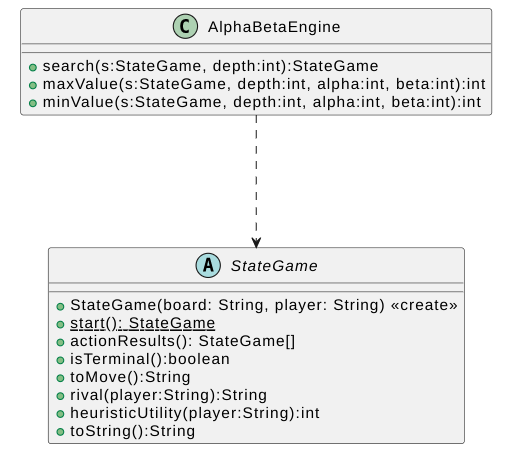

In [87]:
from abc import ABC, abstractmethod
from __future__ import annotations

from typing import List, Optional, Tuple, Dict, Set
import math


## PARTE I. IMPLEMENTACIÓN DE UN JUEGO CON DOS JUGADORES

Implementar un juego para dos jugadores (ambos agentes) del tipo de turnos o estados (teniendo en cuenta la clase *StateGame*).

### GAME THEORY: JUEGO DE ESTADOS

In [88]:
class StateGame(ABC):
  """ Abstracta: define los métodos clave para modelar cualquier juego por turnos (representados en estados)
  """


  @classmethod
  @abstractmethod
  def start(cls) -> StateGame:
    """ Iniciar el juego
    Args:
    Returns:
       el estado inicial del juego
    """
    pass
  @abstractmethod
  def actionResults(self) -> list:
    """ Devuelve los próximos estados correspendientes a los movimientos legales del estado actual
    Args:
    Return:
      listado de estados del juego
    """
    pass
  @abstractmethod
  def isTerminal(self) -> bool:
    """ Evaluar el estado actual, si es un estado que corresponde al fin del jusgo
    Args:
    Returns:
       valor de verdad a la proposición "es un estado meta?"
    """
    pass
  @abstractmethod
  def toMove(self) -> str:
    """ Define que jugador tiene el turno en el estado actual
    Args:
    Returns:
       identificador del jugador
    """
    pass
  @abstractmethod
  def rival(self, player: str) -> str:
    """ Define que jugador es el rival del jugador player
    Args:
      player : identificador de un jugador
    Returns:
       identificador del jugador rival
    """
    pass
  @abstractmethod
  def heuristicUtility(self, player: str) -> int:
    """ Establecer el criterio (heuristica) de utilidad del jugador
    Args:
      player : identificador del jugador
    Returns:
      valor de utilidad
    """
    pass
  @abstractmethod
  def toString(self) -> str:
    """ Muestra el estado del juego en formato de cadena
    Args:
    Returns:
      estado del juego
    """
    pass

Para el juego simple propuesto por su profesor, implemente la clase que lo modela considerando la especificación dada.

In [89]:
# Implementar la clase abstracta y documentar los métodos implementados
class BaghchalState(StateGame):
    """
    Implementación concreta del estado de juego Baghchal.

    """
    __slots__ = (
        "board", "current_player", "goats_to_place",
        "goats_captured", "phase"
    )
 
    def __init__(
        self,
        board: Dict[Tuple[int,int], str],
        current_player: str,
        goats_to_place: int,
        goats_captured: int,
    ) -> None:
        self.board          = board
        self.current_player = current_player
        self.goats_to_place = goats_to_place
        self.goats_captured = goats_captured
        # La fase se determina automáticamente
        self.phase = "PLACE" if goats_to_place > 0 else "MOVE"
        

    @classmethod
    def start(cls) -> "BaghchalState":
        """
        Estado inicial oficial de Baghchal:
          • Los 4 tigres ocupan las esquinas del tablero.
          • El resto del tablero está vacío.
          • Las cabras comienzan fuera del tablero (goats_to_place = 20).
          • El primer turno es de las cabras.
        """
        board: Dict[Tuple[int,int], str] = {}
        for r in range(5):
            for c in range(5):
                board[(r, c)] = EMPTY
 
        # Tigres en las cuatro esquinas
        for corner in [(0,0), (0,4), (4,0), (4,4)]:
            board[corner] = PLAYER_TIGER
 
        return cls(
            board          = board,
            current_player = PLAYER_GOAT,   # cabras mueven primero
            goats_to_place = TOTAL_GOATS,
            goats_captured = 0,
        )
    


 
    def actionResults(self) -> List["BaghchalState"]:
        """
        Genera todos los estados sucesores legales.
 
        Para CABRAS:
          - Fase PLACE: colocar una cabra en cualquier celda vacía.
          - Fase MOVE:  mover una cabra a un vecino vacío adyacente.
          (Las cabras NUNCA capturan.)
 
        Para TIGRES (siempre en fase MOVE, desde el inicio):
          - Mover a un vecino vacío adyacente.
          - Saltar sobre una cabra y capturarla (si la celda de aterrizaje está libre).
 
        Cada resultado es un NUEVO objeto BaghchalState (copia independiente).
        """
        successors: List[BaghchalState] = []
 
        if self.current_player == PLAYER_GOAT:
            successors = self._goat_moves()
        else:
            successors = self._tiger_moves()
 
        return successors
 
    def _goat_moves(self) -> List["BaghchalState"]:
        results: List[BaghchalState] = []
 
        if self.phase == "PLACE":
            # Fase de colocación: una cabra entra a cualquier celda vacía
            for pos, piece in self.board.items():
                if piece == EMPTY:
                    new_board = dict(self.board)
                    new_board[pos] = PLAYER_GOAT
                    results.append(BaghchalState(
                        board          = new_board,
                        current_player = PLAYER_TIGER,
                        goats_to_place = self.goats_to_place - 1,
                        goats_captured = self.goats_captured,
                    ))
        else:
            # Fase de movimiento: mover una cabra a un vecino vacío
            for pos, piece in self.board.items():
                if piece == PLAYER_GOAT:
                    for neighbor in ADJACENCY[pos]:
                        if self.board[neighbor] == EMPTY:
                            new_board = dict(self.board)
                            new_board[pos]      = EMPTY
                            new_board[neighbor] = PLAYER_GOAT
                            results.append(BaghchalState(
                                board          = new_board,
                                current_player = PLAYER_TIGER,
                                goats_to_place = 0,
                                goats_captured = self.goats_captured,
                            ))
 
        return results
    
 
    def _tiger_moves(self) -> List["BaghchalState"]:
        results: List[BaghchalState] = []
 
        for pos, piece in self.board.items():
            if piece == PLAYER_TIGER:
                # Movimientos simples a vecinos vacíos
                for neighbor in ADJACENCY[pos]:
                    if self.board[neighbor] == EMPTY:
                        new_board = dict(self.board)
                        new_board[pos]      = EMPTY
                        new_board[neighbor] = PLAYER_TIGER
                        results.append(BaghchalState(
                            board          = new_board,
                            current_player = PLAYER_GOAT,
                            goats_to_place = self.goats_to_place,
                            goats_captured = self.goats_captured,
                        ))
 
                # Saltos de captura
                for mid, landing in JUMP_TARGETS[pos]:
                    if (self.board[mid]     == PLAYER_GOAT
                            and self.board[landing] == EMPTY):
                        new_board = dict(self.board)
                        new_board[pos]     = EMPTY
                        new_board[mid]     = EMPTY          # cabra capturada
                        new_board[landing] = PLAYER_TIGER
                        results.append(BaghchalState(
                            board          = new_board,
                            current_player = PLAYER_GOAT,
                            goats_to_place = self.goats_to_place,
                            goats_captured = self.goats_captured + 1,
                        ))
 
        return results
    
     
    def isTerminal(self) -> bool:
        """
        El juego termina si:
          1. Los tigres capturaron 5 o más cabras → victoria tigres.
          2. Todos los tigres están completamente inmovilizados → victoria cabras.
        """
        if self.goats_captured >= GOATS_TO_WIN:
            return True
        if self._all_tigers_immobile():
            return True
        return False
    
    def _all_tigers_immobile(self) -> bool:
        """
        Un tigre está inmovilizado si no puede moverse a ningún vecino libre
        ni realizar ningún salto de captura válido.
        Los tigres de cabras ganan solo si TODOS están inmovilizados.
        """
        for pos, piece in self.board.items():
            if piece == PLAYER_TIGER:
                # ¿Puede moverse a algún vecino libre?
                for neighbor in ADJACENCY[pos]:
                    if self.board[neighbor] == EMPTY:
                        return False
                # ¿Puede realizar algún salto de captura?
                for mid, landing in JUMP_TARGETS[pos]:
                    if (self.board[mid] == PLAYER_GOAT
                            and self.board[landing] == EMPTY):
                        return False
        return True
    


    def toMove(self) -> str:
        return self.current_player
 
    def rival(self, player: str) -> str:
        return PLAYER_GOAT if player == PLAYER_TIGER else PLAYER_TIGER
    



    def heuristicUtility(self, player: str) -> int:
        """
 
        ESTADOS TERMINALES:
          • Tigres ganan (5 capturas) → +10 000 para tigres / -10 000 para cabras
          • Cabras ganan (tigres inmovilizados) → +10 000 para cabras / -10 000 para tigres
 
        FACTORES PARA TIGRES:
 
        1. goats_captured × 1000
           Las capturas son el objetivo directo. Cada cabra capturada acerca
           el fin del juego. Peso alto para que la IA priorice siempre capturar.
 
        2. tiger_mobility × 15
           Un tigre con libertad de movimiento es amenazante. La movilidad
           total de los 4 tigres mide cuántas opciones de ataque/movimiento
           tienen. Incentiva mantener los tigres activos.
 
        3. capture_threats × 200
           Una amenaza de captura (cabra que puede ser saltada en el próximo
           turno) es una ventaja táctica inmediata. Peso alto porque puede
           forzar movimientos defensivos al rival.
 
        4. tiger_center_control × 8
           Los tigres en el centro o zonas de alta conectividad tienen más
           opciones de movimiento y captura. El centro del tablero (2,2) y
           sus adyacentes son las posiciones más valiosas para los tigres.
 
        5. free_tigers × 30
           Un tigre «libre» (con al menos un movimiento legal disponible)
           contribuye activamente al juego. Tigres bloqueados no sirven.
 
        FACTORES PARA CABRAS:
 
        1. blocked_tigers × 250
           Cada tigre inmovilizado reduce la amenaza. Si los 4 están bloqueados
           → victoria. Peso muy alto porque es el objetivo terminal.
 
        2. tiger_mobility_penalty × 12
           Reducir la movilidad del enemigo es el equivalente de «apretar».
           Cuantos menos movimientos tienen los tigres, más seguros están los
           cabras y más cerca está la victoria.
 
        3. goats_safe × 5
           Las cabras en posiciones bien conectadas y protegidas son activos.
           Mide cuántas cabras tienen al menos 2 vecinos con otras cabras
           (formación defensiva).
 
        4. goats_placed_bonus × 3
           En la fase de colocación, cada cabra colocada acerca al estado
           donde se puede ejecutar una estrategia de bloqueo efectiva.
        """
 
        if self.goats_captured >= GOATS_TO_WIN:
            # Los tigres ganaron
            return 10_000 if player == PLAYER_TIGER else -10_000
 
        if self._all_tigers_immobile():
            # Las cabras ganaron
            return 10_000 if player == PLAYER_GOAT else -10_000
 
        tiger_positions: List[Tuple[int,int]] = []
        goat_positions:  List[Tuple[int,int]] = []
 
        for pos, piece in self.board.items():
            if piece == PLAYER_TIGER:
                tiger_positions.append(pos)
            elif piece == PLAYER_GOAT:
                goat_positions.append(pos)
 
        goat_set: Set[Tuple[int,int]] = set(goat_positions)
 
        # ── Métricas de movilidad de tigres ───────────────────────────────
        tiger_simple_moves   = 0
        tiger_capture_moves  = 0
        capture_threats      = 0
        free_tigers          = 0
        blocked_tigers       = 0
        tiger_center_score   = 0.0
 
        for tpos in tiger_positions:
            moves_available = 0
 
            for neighbor in ADJACENCY[tpos]:
                if self.board[neighbor] == EMPTY:
                    tiger_simple_moves += 1
                    moves_available    += 1
 
            for mid, landing in JUMP_TARGETS[tpos]:
                if (self.board[mid] == PLAYER_GOAT
                        and self.board[landing] == EMPTY):
                    tiger_capture_moves += 1
                    capture_threats     += 1
                    moves_available     += 1
 
            if moves_available > 0:
                free_tigers += 1
            else:
                blocked_tigers += 1
 
            tiger_center_score += CENTER_WEIGHTS[tpos]
 
        tiger_mobility = tiger_simple_moves + tiger_capture_moves
 
        # ── Métricas de formación defensiva de cabras ─────────────────────
        goats_in_formation = 0
        for gpos in goat_positions:
            goat_neighbors_count = sum(
                1 for nb in ADJACENCY[gpos] if nb in goat_set
            )
            if goat_neighbors_count >= 2:
                goats_in_formation += 1
 
        goats_placed = TOTAL_GOATS - self.goats_to_place
 
        # ── Puntuación para TIGRES ─────────────────────────────────────────
        tiger_score = (
              self.goats_captured * 1000
            + tiger_mobility      * 15
            + capture_threats     * 200
            + tiger_center_score  * 8
            + free_tigers         * 30
            - blocked_tigers      * 400
        )
 
        # ── Puntuación para CABRAS ─────────────────────────────────────────
        goat_score = (
              blocked_tigers       * 250
            + (12 - tiger_mobility) * 20
            + goats_in_formation   * 5
            + goats_placed         * 3
            - self.goats_captured  * 400
        )
 
        # ── Retorno según perspectiva del jugador ─────────────────────────
        if player == PLAYER_TIGER:
            return int(tiger_score - goat_score * 0.4)
        else:
            return int(goat_score - tiger_score * 0.4)
  
    def toString(self) -> str:
        """
        Visualización del tablero en texto para depuración.
        T = Tigre, G = Cabra, . = Vacío
        """
        lines = []
        lines.append(
            f"Turno: {'TIGRES' if self.current_player == PLAYER_TIGER else 'CABRAS'} | "
            f"Fase: {self.phase} | "
            f"Cabras por colocar: {self.goats_to_place} | "
            f"Cabras capturadas: {self.goats_captured}"
        )
        lines.append("  0   1   2   3   4")
        for r in range(5):
            row_chars = []
            for c in range(5):
                cell = self.board[(r, c)]
                row_chars.append(cell if cell != EMPTY else ".")
            lines.append(f"{r} " + " ─ ".join(row_chars))
            if r < 4:
                # Muestra conexiones verticales
                v_line = "  "
                for c in range(5):
                    v_line += "|   "
                lines.append(v_line)
        return "\n".join(lines)
 
 

In [90]:
"""
REPRESENTACIÓN DEL TABLERO 5×5
────────────────────────────────
Las 25 posiciones se indexan de (0,0) a (4,4):
 
  (0,0)─(0,1)─(0,2)─(0,3)─(0,4)
    │  ╲  │  ╱  │  ╲  │  ╱  │
  (1,0)─(1,1)─(1,2)─(1,3)─(1,4)
    │  ╱  │  ╲  │  ╱  │  ╲  │
  (2,0)─(2,1)─(2,2)─(2,3)─(2,4)
    │  ╲  │  ╱  │  ╲  │  ╱  │
  (3,0)─(3,1)─(3,2)─(3,3)─(3,4)
    │  ╱  │  ╲  │  ╱  │  ╲  │
  (4,0)─(4,1)─(4,2)─(4,3)─(4,4)
 
Las diagonales solo existen donde ambas coordenadas son pares o ambas impares. Esta regla define exactamente qué posiciones tienen conexión diagonal y cuales no.
 
Un nodo (r,c) tiene diagonal si y solo si (r+c) es par.
"""
 
def _build_adjacency() -> Dict[Tuple[int,int], List[Tuple[int,int]]]:
    """
    Construye el grafo de adyacencia real del tablero Baghchal 5×5.
 
    Reglas de conectividad:
      • Todos los nodos tienen conexiones ortogonales (arriba/abajo/izq/der)
        siempre que el vecino esté dentro del tablero.
      • Un nodo tiene conexiones diagonales SOLO si (fila + columna) es par.
        Esto reproduce el patrón real de líneas del tablero de Baghchal.
 
    Retorna: dict de (fila, col) → lista de vecinos directos (distancia 1).
    """
    adj: Dict[Tuple[int,int], List[Tuple[int,int]]] = {}
 
    for r in range(5):
        for c in range(5):
            neighbors: List[Tuple[int,int]] = []
 
            # Conexiones ortogonales (siempre válidas)
            for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
                nr, nc = r+dr, c+dc
                if 0 <= nr < 5 and 0 <= nc < 5:
                    neighbors.append((nr, nc))
 
            # Conexiones diagonales (solo si (r+c) es par)
            if (r + c) % 2 == 0:
                for dr, dc in [(-1,-1),(-1,1),(1,-1),(1,1)]:
                    nr, nc = r+dr, c+dc
                    if 0 <= nr < 5 and 0 <= nc < 5:
                        neighbors.append((nr, nc))
 
            adj[(r, c)] = neighbors
 
    return adj
 
 
def _build_jump_targets(
    adj: Dict[Tuple[int,int], List[Tuple[int,int]]]
) -> Dict[Tuple[int,int], List[Tuple[Tuple[int,int], Tuple[int,int]]]]:
    """
    Para cada posición, calcula los posibles saltos de captura de tigre.
 
    Un tigre en A puede saltar sobre una cabra en B y aterrizar en C si:
      • B es vecino directo de A (en el grafo de adyacencia).
      • C es vecino directo de B, en la MISMA DIRECCIÓN que A→B.
      • C está vacío.
 
    Retorna: dict de posición → lista de (intermedio, destino)
    """
    jumps: Dict[Tuple[int,int], List[Tuple[Tuple[int,int], Tuple[int,int]]]] = {}
 
    for pos in adj:
        r, c = pos
        jump_list = []
        for neighbor in adj[pos]:
            nr, nc = neighbor
            dr, dc = nr - r, nc - c          # dirección del salto
            landing = (nr + dr, nc + dc)     # celda de aterrizaje
            if (0 <= landing[0] < 5 and 0 <= landing[1] < 5
                    and landing in adj[neighbor]):  # conexión válida
                jump_list.append((neighbor, landing))
        jumps[pos] = jump_list
 
    return jumps
 
 
# Grafos precalculados (constantes globales, solo se computan una vez)
ADJACENCY: Dict[Tuple[int,int], List[Tuple[int,int]]] = _build_adjacency()
JUMP_TARGETS: Dict[
    Tuple[int,int], List[Tuple[Tuple[int,int], Tuple[int,int]]]
] = _build_jump_targets(ADJACENCY)
 
# Constantes del juego
TOTAL_GOATS      = 20
GOATS_TO_WIN     = 5    # capturas necesarias para que los tigres ganen
PLAYER_TIGER     = "T"
PLAYER_GOAT      = "G"
EMPTY            = "."
 
# Bonificación de centro para heurística
CENTER_WEIGHTS: Dict[Tuple[int,int], float] = {
    (r, c): max(0, 2 - max(abs(r-2), abs(c-2)))
    for r in range(5) for c in range(5)
}
 
 

## PARTE II. IMPLEMENTACIÓN DE BÚSQUEDA: MINIMAX $\alpha$ - $\beta$

Implementar la lógica de búsqueda adversaria para que el jugador tome una decisión y generé una acción (la mejor posible)

### BÚSQUEDA ADVERSARIA: MINIMAX PODA $\alpha$ - $\beta$

In [91]:
class AlphaBetaEngine():
  """ Algoritmo de búsqueda adversaria MiniMax con poda (optimización) por AlphaBeta
  """


  def __init__(self) -> None:
    self._root_player: str = PLAYER_TIGER  # se actualiza en search()
    self.nodes_explored: int = 0


  def search(self, s: StateGame, depth: int) -> Optional[StateGame]:
    """ Generar mejor acción/transición del juego a partir de un estado
    Args:
       s : estado de juego
       depth : profundidad de búsqueda deseada
    Returns:
       siguiente estado decidido
    """
    self._root_player = s.toMove()
    self.nodes_explored = 0

    best_state:  Optional[StateGame] = None
    best_value:  int = -math.inf
    alpha: int = -math.inf
    beta:  int =  math.inf
 
    successors = s.actionResults()
    if not successors:
        return None
 
    for successor in successors:
        val = self.minValue(successor, depth - 1, alpha, beta)
        if val > best_value:
            best_value = val
            best_state = successor
        alpha = max(alpha, best_value)
 
    return best_state

  def maxValue(self, s: StateGame, depth: int, alpha: int, beta: int) -> int:
    """ Evaluar valor para MAX
    Args:
       s : estado de juego
       depth : profundidad de búsqueda deseada
       alpha : valor de criterio alfa
       beta : valor de criterio beta
    Return:
      valor calculado para MAX
    """
    self.nodes_explored += 1
 
    if s.isTerminal():
        return s.heuristicUtility(self._root_player)
    if depth == 0:
        return s.heuristicUtility(self._root_player)
 
    successors = s.actionResults()
    if not successors:
        return s.heuristicUtility(self._root_player)
 
    v: int = -math.inf
 
    for successor in successors:
        v2 = self.minValue(successor, depth - 1, alpha, beta)
        if v2 > v:
            v = v2
        alpha = max(alpha, v)
        if v >= beta:
            return v   
    return v

  def minValue(self, s: StateGame, depth: int, alpha: int, beta: int) -> int:
    """ Evaluar valor para MIN
    Args:
       s : estado de juego
       depth : profundidad de búsqueda deseada
       alpha : valor de criterio alfa
       beta : valor de criterio beta
    Returns:
       valor calculado para MIN
    """
    self.nodes_explored += 1
 
    if s.isTerminal():
        return s.heuristicUtility(self._root_player)
    if depth == 0:
        return s.heuristicUtility(self._root_player)
 
    successors = s.actionResults()
    if not successors:
        return s.heuristicUtility(self._root_player)
 
    v: int = math.inf
 
    for successor in successors:
        v2 = self.maxValue(successor, depth - 1, alpha, beta)
        if v2 < v:
            v = v2
        beta = min(beta, v)
        if v <= alpha:
            return v
    return v

In [92]:
# A partir de dos posibles estados iniciales, pruebe el desarrollo del juego y las decisiones por heurisrica MiniMax

In [93]:

def determine_winner(state: BaghchalState) -> str:
    """Determina el ganador de un estado terminal."""
    if state.goats_captured >= GOATS_TO_WIN:
        return "TIGRES"
    if state._all_tigers_immobile():
        return "CABRAS"
    return "INDEFINIDO"
 
 
def play_game(
    tiger_depth: int = 4,
    goat_depth: int  = 4,
    max_turns: int   = 300
) -> None:
    """
    Ejecuta una partida completa Tigres vs Cabras.
 
    Parámetros:
      tiger_depth : profundidad de búsqueda para el motor de tigres
      goat_depth  : profundidad de búsqueda para el motor de cabras
      max_turns   : límite de turnos para evitar juegos infinitos
    """
    engine = AlphaBetaEngine()
    state: BaghchalState = BaghchalState.start()
    turn = 0
 
    print("=" * 60)
    print("         BAGHCHAL — Tiger & Goats")
    print("=" * 60)
    print(state.toString())
    print()
 
    while not state.isTerminal() and turn < max_turns:
        turn += 1
        current = state.toMove()
        depth   = tiger_depth if current == PLAYER_TIGER else goat_depth
 
        print(f"── Turno {turn}: {'TIGRES' if current == PLAYER_TIGER else 'CABRAS'} "
              f"(depth={depth}) ──")
 
        engine.nodes_explored = 0
        next_state = engine.search(state, depth)
 
        if next_state is None:
            print("  Sin movimientos disponibles — empate/bloqueo.")
            break
 
        print(f"  Nodos explorados: {engine.nodes_explored}")
        print(next_state.toString())
        print()
        state = next_state  # type: ignore[assignment]
 
    print("=" * 60)
    if state.isTerminal():
        winner = determine_winner(state)
        print(f"  JUEGO TERMINADO — Ganador: {winner}")
        print(f"  Cabras capturadas: {state.goats_captured}")
    else:
        print(f"  Límite de {max_turns} turnos alcanzado — empate forzado.")
    print("=" * 60)

In [94]:

def run_tests() -> None:
    """
    Conjunto de pruebas unitarias para verificar la corrección del motor.
    Verifica: conectividad, generación de movimientos, condiciones terminales,
    heurística y funcionamiento del Alpha-Beta.
    """
    print("\n" + "="*60)
    print("              SUITE DE TESTS")
    print("="*60)
 
    # ── Test 1: Conectividad del tablero ──────────────────────────────────
    # (0,0) es esquina: debe tener vecinos ortogonales (0,1) y (1,0)
    # y vecino diagonal (1,1) porque (0+0)%2==0
    assert (0,1) in ADJACENCY[(0,0)], "Error: (0,1) no es vecino de (0,0)"
    assert (1,0) in ADJACENCY[(0,0)], "Error: (1,0) no es vecino de (0,0)"
    assert (1,1) in ADJACENCY[(0,0)], "Error: diagonal (1,1) falta en (0,0)"
    # (0,1): (0+1)%2==1 → no diagonales
    assert (1,0) not in ADJACENCY[(0,1)] or True  # ortogonal sí existe
    # Verificar que (1,2) NO es diagonal de (0,1) (suma impar → no diag)
    diag_01 = [(0+dr, 1+dc) for dr,dc in [(-1,-1),(-1,1),(1,-1),(1,1)]
               if 0<=0+dr<5 and 0<=1+dc<5]
    for d in diag_01:
        assert d not in ADJACENCY[(0,1)], \
            f"Error: diagonal {d} no debería existir en (0,1)"
    print("✓ Test 1: Conectividad del tablero — OK")
 
    # ── Test 2: Estado inicial ────────────────────────────────────────────
    s0 = BaghchalState.start()
    assert s0.board[(0,0)] == PLAYER_TIGER
    assert s0.board[(0,4)] == PLAYER_TIGER
    assert s0.board[(4,0)] == PLAYER_TIGER
    assert s0.board[(4,4)] == PLAYER_TIGER
    assert s0.goats_to_place == 20
    assert s0.goats_captured == 0
    assert s0.toMove() == PLAYER_GOAT
    assert s0.phase == "PLACE"
    assert not s0.isTerminal()
    print("✓ Test 2: Estado inicial — OK")
 
    # ── Test 3: Generación de movimientos iniciales ───────────────────────
    # En el estado inicial, las cabras pueden colocarse en 21 celdas vacías
    moves = s0.actionResults()
    assert len(moves) == 21, f"Esperados 21 movimientos, obtenidos {len(moves)}"
    # Cada sucesor tiene una cabra más
    for m in moves:
        assert m.goats_to_place == 19
        assert m.current_player == PLAYER_TIGER
    print("✓ Test 3: Generación de movimientos de cabras (fase place) — OK")
 
    # ── Test 4: Condición de victoria de tigres ───────────────────────────
    # Estado artificial: 5 cabras capturadas
    s_tiger_win = BaghchalState(
        board          = dict(s0.board),
        current_player = PLAYER_GOAT,
        goats_to_place = 15,
        goats_captured = 5,
    )
    assert s_tiger_win.isTerminal()
    assert s_tiger_win.heuristicUtility(PLAYER_TIGER) == 10_000
    assert s_tiger_win.heuristicUtility(PLAYER_GOAT)  == -10_000
    print("✓ Test 4: Victoria de tigres — OK")
 
    # ── Test 5: Condición de victoria de cabras ───────────────────────────
    # Para inmovilizar un tigre debemos bloquear TODOS sus vecinos simples
    # Y también bloquear todos sus saltos de captura (celda de aterrizaje ocupada).
    # Construimos un tablero donde los 4 tigres están en el centro de filas/col
    # y completamente rodeados sin celdas de aterrizaje libres.
    #
    # Usamos un estado sintético con 4 tigres apiñados en (2,1)(2,2)(2,3)(1,2)
    # y cabras llenando todos los vecinos y celdas de aterrizaje.
    blocked_board2: Dict[Tuple[int,int], str] = {(r,c): PLAYER_GOAT
                                                  for r in range(5) for c in range(5)}
    tiger_positions_test = [(2,1),(2,3),(1,2),(3,2)]
    for tp in tiger_positions_test:
        blocked_board2[tp] = PLAYER_TIGER
 
    s_goat_win = BaghchalState(
        board          = blocked_board2,
        current_player = PLAYER_TIGER,
        goats_to_place = 0,
        goats_captured = 0,
    )
    # Verificar que ningún tigre puede moverse ni capturar
    assert s_goat_win._all_tigers_immobile(), \
        "Error: tigres deberían estar completamente inmovilizados"
    assert s_goat_win.isTerminal(), "Error: estado con tigres bloqueados debe ser terminal"
    assert s_goat_win.heuristicUtility(PLAYER_GOAT)  == 10_000
    assert s_goat_win.heuristicUtility(PLAYER_TIGER) == -10_000
    print("✓ Test 5: Victoria de cabras (inmovilización) — OK")
 
    # ── Test 6: Motor Alpha-Beta retorna un estado válido ─────────────────
    engine = AlphaBetaEngine()
    result = engine.search(s0, depth=2)
    assert result is not None
    assert isinstance(result, BaghchalState)
    assert result.current_player == PLAYER_TIGER  # cabra movió → turno tigre
    print(f"✓ Test 6: Alpha-Beta depth=2 — OK "
          f"(nodos explorados: {engine.nodes_explored})")
 
    # ── Test 7: Inmutabilidad — el estado original no se modifica ─────────
    original_board = dict(s0.board)
    _ = s0.actionResults()
    assert s0.board == original_board, "Error: actionResults() modificó el estado"
    print("✓ Test 7: Inmutabilidad del estado — OK")
 
    # ── Test 8: Saltos de captura correctos ───────────────────────────────
    # Colocar un tigre en (2,2), cabra en (2,3), celda (2,4) vacía
    capture_board = {(r,c): EMPTY for r in range(5) for c in range(5)}
    capture_board[(2,2)] = PLAYER_TIGER
    capture_board[(2,3)] = PLAYER_GOAT
    s_capture = BaghchalState(
        board=capture_board, current_player=PLAYER_TIGER,
        goats_to_place=0, goats_captured=0
    )
    tiger_moves = s_capture.actionResults()
    # Debe existir al menos un movimiento de captura
    capture_moves = [m for m in tiger_moves if m.goats_captured == 1]
    assert len(capture_moves) > 0, "Error: no se generó movimiento de captura"
    cap = capture_moves[0]
    assert cap.board[(2,3)] == EMPTY, "La cabra capturada debe desaparecer"
    assert cap.board[(2,2)] == EMPTY, "El tigre debe dejar su posición"
    print("✓ Test 8: Capturas de tigres — OK")
 
    # ── Test 9: Rival ─────────────────────────────────────────────────────
    assert s0.rival(PLAYER_TIGER) == PLAYER_GOAT
    assert s0.rival(PLAYER_GOAT)  == PLAYER_TIGER
    print("✓ Test 9: rival() — OK")
 
    print("\n✓ Todos los tests pasaron correctamente.")
    print("="*60)

In [95]:
run_tests()


              SUITE DE TESTS
✓ Test 1: Conectividad del tablero — OK
✓ Test 2: Estado inicial — OK
✓ Test 3: Generación de movimientos de cabras (fase place) — OK
✓ Test 4: Victoria de tigres — OK
✓ Test 5: Victoria de cabras (inmovilización) — OK
✓ Test 6: Alpha-Beta depth=2 — OK (nodos explorados: 105)
✓ Test 7: Inmutabilidad del estado — OK
✓ Test 8: Capturas de tigres — OK
✓ Test 9: rival() — OK

✓ Todos los tests pasaron correctamente.


In [96]:
print("\nIniciando partida Baghchal(depth=3)\n")
play_game(tiger_depth=3, goat_depth=3, max_turns=200)


Iniciando partida Baghchal(depth=3)

         BAGHCHAL — Tiger & Goats
Turno: CABRAS | Fase: PLACE | Cabras por colocar: 20 | Cabras capturadas: 0
  0   1   2   3   4
0 T ─ . ─ . ─ . ─ T
  |   |   |   |   |   
1 . ─ . ─ . ─ . ─ .
  |   |   |   |   |   
2 . ─ . ─ . ─ . ─ .
  |   |   |   |   |   
3 . ─ . ─ . ─ . ─ .
  |   |   |   |   |   
4 T ─ . ─ . ─ . ─ T

── Turno 1: CABRAS (depth=3) ──
  Nodos explorados: 1271
Turno: TIGRES | Fase: PLACE | Cabras por colocar: 19 | Cabras capturadas: 0
  0   1   2   3   4
0 T ─ . ─ . ─ . ─ T
  |   |   |   |   |   
1 . ─ . ─ . ─ . ─ .
  |   |   |   |   |   
2 . ─ . ─ G ─ . ─ .
  |   |   |   |   |   
3 . ─ . ─ . ─ . ─ .
  |   |   |   |   |   
4 T ─ . ─ . ─ . ─ T

── Turno 2: TIGRES (depth=3) ──
  Nodos explorados: 806
Turno: CABRAS | Fase: PLACE | Cabras por colocar: 19 | Cabras capturadas: 0
  0   1   2   3   4
0 . ─ . ─ . ─ . ─ T
  |   |   |   |   |   
1 . ─ T ─ . ─ . ─ .
  |   |   |   |   |   
2 . ─ . ─ G ─ . ─ .
  |   |   |   |   |   
3 . ─ . ─ . 

## RETROSPECTIVA

**1.** ¿Cuál fue el tiempo total invertido en el laboratorio por cada uno de ustedes? (Horas/Hombre)

Ambos dedicamos 5 horas.

**2.** ¿Cuál es el estado actual del laboratorio? ¿Por qué?

Terminado ya que hemos consultado bastantes fuentes, incluso la del libro para la implementacion.
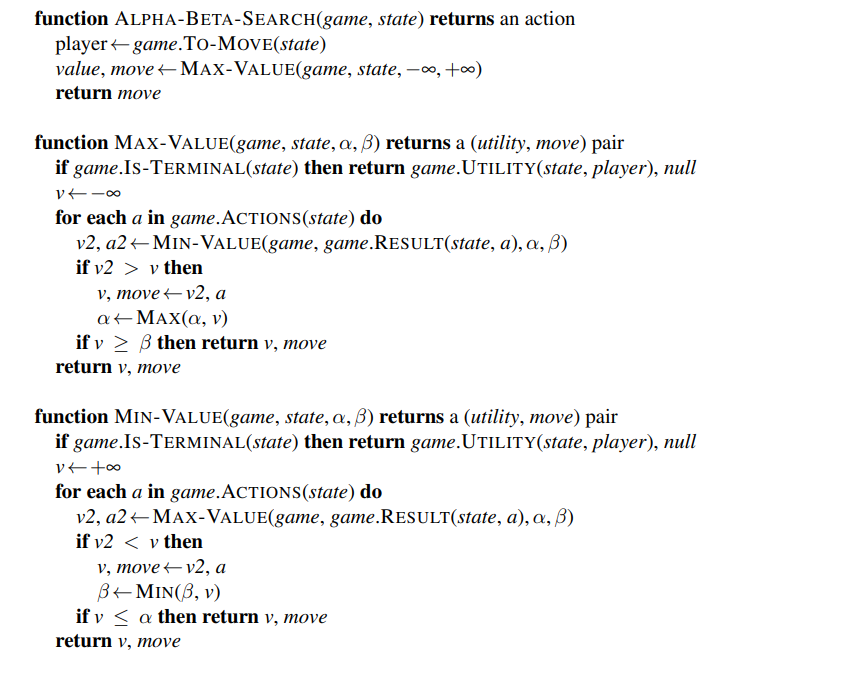

**3.** ¿Cuál consideran fue el mayor logro? ¿Por qué?

Consideramos que el mayor logro fue implementar correctamente el motor de búsqueda Alpha-Beta.

**4.** ¿Cuál consideran que fue el mayor problema técnico? ¿Qué hicieron para resolverlo?

El mayor problema que encontramos es principalmente como representamos tanto el tablero como las reglas de Baghchal, especialmente las conexiones diagonales y las capturas de los tigres.


**5.** ¿Qué hicieron bien como equipo? ¿Qué se comprometen a hacer para mejorar los resultados?

Principalmente resaltamos la comunicacion y el trabajo en equipo ya que pudimos tomar decisiones respecto a como manejar los errores y los problemas que iban surgiendo.

**6**.¿Qué referencias usaron? ¿Cuál fue la más útil? Incluya citas con los estándares adecuados.

La mas util consideramos que es el libro de texto.

Russell, S., & Norvig, P. (2021). Artificial Intelligence: A Modern Approach (4th ed.). Pearson.
GeeksforGeeks. (2024). Minimax Algorithm in Game Theory | Set 4 (Alpha-Beta Pruning). Recuperado de:
https://www.geeksforgeeks.org/minimax-algorithm-in-game-theory-set-4-alpha-beta-pruning/

*Incluyan las respuesta*